# Домашнее задание 1. Постановка и классификация задач, МНК, LP

**Выдано:** 9 сентября 2026. **Срок сдачи:** 23 сентября 2026 (до начала занятия). **Максимум:** 10 баллов (+1 бонус).

**Как сдавать.** Заполните этот ноутбук (ответы на теоретические вопросы — в markdown-ячейках, формулы в $\LaTeX$; код — в code-ячейках) и пришлите `.ipynb` **с выполненными ячейками** и его PDF-экспорт (`File → Save and Export Notebook As → PDF` или `HTML → печать в PDF`). Задачи можно обсуждать, но текст и код пишутся самостоятельно.

**Материал:** лекция 1 ([конспект](../lectures/lecture01/lecture01.md), [демо](../lectures/lecture01/demo01.ipynb)). Ничего сверх лекции не требуется.

Запуск: `uv sync` в корне репозитория, затем `uv run jupyter lab`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog, minimize

rng = np.random.default_rng(2026)   # не меняйте seed: данные должны совпадать у всех

## Задача 1. Классификация (4 балла)

Для каждой задачи (а)–(г) запишите её в стандартной форме

$$\min_x f(x) \quad\text{при}\quad g(x) = 0,\; h(x) \ge 0,$$

явно указав, что такое $x$ (и его размерность), $f$, $g$, $h$. Затем определите класс: LP / QP / QCQP / NLP; с ограничениями или без; выпуклая или нет (обоснуйте там, где это очевидно). По 1 баллу за пункт.

**(а)** Найти точку прямой $\{x \in \mathbb{R}^3 : x_1 + x_2 + x_3 = 1,\; x_1 - x_3 = 0\}$, ближайшую к точке $(1, 2, 3)$. *Дополнительно:* найдите эту точку (руками или численно).

**(б)** Диета: $n$ продуктов с ценами $c_j$; $m$ питательных веществ, продукт $j$ содержит $A_{ij}$ единиц вещества $i$. Купить продукты минимальной стоимости так, чтобы каждого вещества было не меньше $b_i$.

**(в)** Найти вписанный в единичный круг прямоугольник наибольшей площади (стороны параллельны осям).

**(г)** Подогнать модель $\varphi(t; x) = x_1 \sin(x_2 t + x_3)$ к измерениям $(t_i, y_i)$, $i = 1, \dots, N$, по критерию суммы квадратов невязок.

**(д, бонус +1)** $\min_{x \in \mathbb{R}^n} \max_i |a_i^\top x - b_i|$ (подгонка в чебышёвской норме). Переформулируйте как гладкую задачу с одной дополнительной переменной, по образцу переформулировки из раздела 8 лекции. Какой это класс?

**(а)**

**Ответ:**

Стандартная форма: $x \in \mathbb{R}^3$, $f(x) = \tfrac12\big[(x_1 - 1)^2 + (x_2 - 2)^2 + (x_3 - 3)^2\big]$, $g(x) = (x_1 + x_2 + x_3 - 1, x_1 - x_3)$.

Класс задачи: квадратичная целевая функция, линейные ограничения $\Rightarrow$ QP.

По наличию ограничений: с ограничениями-равенствами.

Выпуклость: $f$ выпукла: $Q = I_3 = \begin{pmatrix} 1 & 0 & 0 \\ 0 & 1 & 0 \\ 0 & 0 & 1\end{pmatrix} \succeq 0 $, $g$ афинна $\Rightarrow$ задача выпуклая.

In [2]:
def f1(x):
    return 0.5 * ((x[0] - 1) ** 2 + (x[1] - 2) ** 2 + (x[2] - 3) ** 2)

res = minimize(f1, x0=[0.0, 0.0, 0.0], method="SLSQP", constraints=[{"type": "eq", "fun": lambda x: x[0] + x[1] + x[2] - 1}, {"type": "eq", "fun": lambda x: x[0] - x[2]}])
res.x


array([0.33333333, 0.33333333, 0.33333333])

**(б)**

**Ответ:**

Стандартная форма: $x \in \mathbb{R}^n$, $f(x) = c^\top x$, $h(x) = (x, Ax - b)$.

Класс задачи: LP.

По наличию ограничений: с ограничениями-неравенствами.

Выпуклость: LP всегда выпукла.

**(в)**

**Ответ:**

Стандартная форма: $x \in \mathbb{R}^2$, $f(x) = - x_1 x_2$, $g(x) = x_1^2 + x_2^2 - 4$, $h(x) = (x_1, x_2)$.

Класс задачи: квадратичная целевая функция, квадратичные ограничения $\Rightarrow$ QCQP.

По наличию ограничений: с ограничениями.

Выпуклость: $Q = \begin{pmatrix} 0 & -1 \\ -1 & 0\end{pmatrix}$, собственные числа равны $\pm 1$ $\Rightarrow$ невыпукла.

**(г)**

**Ответ:**

Стандартная форма: $x \in \mathbb{R}^3$, $f(x) = \tfrac12 \sum_{i=1}^N \big(\varphi(t_i;x) - y_i\big)^2 = \tfrac12 \sum_{i=1}^N \big(x_1 \sin(x_2 t_i + x_3) - y_i\big)^2$.

Класс задачи: целевая функция нелинейная и не квадратичная по $x$ $\Rightarrow$ NLP.

По наличию ограничений: безусловная оптимизация.

Выпуклость: нелинейный МНК $\Rightarrow$ невыпукла.

**(д, бонус)**

**Ответ:** _(ваш текст; формулы — в $\LaTeX$)_

## Задача 2. Практика (6 баллов)

**(а) Линейный МНК и переобучение (3 балла).** Ниже сгенерированы обучающая и тестовая выборки: $y = \sin(2\pi t) + \varepsilon$, $\varepsilon \sim \mathcal{N}(0, 0.1^2)$. Для каждой степени $d = 1, \dots, 15$ подгоните полином $\varphi(t; x) = x_0 + x_1 t + \dots + x_d t^d$ методом наименьших квадратов (`numpy.linalg.lstsq`; матрицу $A$ удобно строить через `np.vander(t, d + 1, increasing=True)`). Постройте график зависимости среднеквадратичной ошибки на обучающей и на тестовой выборках от $d$ (ось $y$ — логарифмическая). Объясните поведение обеих кривых в двух-трёх предложениях: почему одна монотонна, а другая нет?

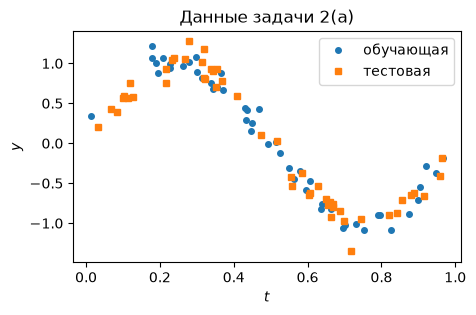

In [3]:
N = 50
t_train = np.sort(rng.uniform(0, 1, N))
y_train = np.sin(2 * np.pi * t_train) + 0.1 * rng.standard_normal(N)
t_test = np.sort(rng.uniform(0, 1, N))
y_test = np.sin(2 * np.pi * t_test) + 0.1 * rng.standard_normal(N)

plt.figure(figsize=(5, 3))
plt.plot(t_train, y_train, "o", ms=4, label="обучающая")
plt.plot(t_test, y_test, "s", ms=4, label="тестовая")
plt.legend(); plt.xlabel("$t$"); plt.ylabel("$y$"); plt.title("Данные задачи 2(а)")
plt.show()

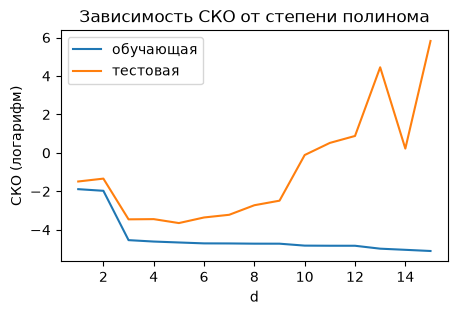

In [4]:
def design(t, deg):
    return np.vander(t, deg + 1, increasing=True)

d_range = [i for i in range (1, 16)]
rmse_train = []
rmse_test = []

for d in d_range:
    A_train = design(t_train, d)
    x_lstsq, *_ = np.linalg.lstsq(A_train, y_train, rcond=None)
    y_train_pred = A_train @ x_lstsq
    rmse_train.append(np.log(np.mean((y_train - y_train_pred)**2)))

    A_test = design(t_test, d)
    y_test_pred = A_test @ x_lstsq
    rmse_test.append(np.log(np.mean((y_test - y_test_pred)**2)))

plt.figure(figsize=(5, 3))
plt.plot(d_range, rmse_train, label="обучающая")
plt.plot(d_range, rmse_test, label="тестовая")
plt.legend(); plt.xlabel("d"); plt.ylabel("СКО (логарифм)"); plt.title("Зависимость СКО от степени полинома")
plt.show()

**Ответ:** Значение среднеквадратичного отклонения для обучающей выборки монотонно убывает, так как с ростом степени полинома модель подстраивается под обучающие данные. На тестовой выборке при маленьких степенях модель слишком простая, но ошибка убывает, однако при больших степенях модель становится чувствительной к шуму в обучающей выборке (переобучается), и ошибка растет.

**(б) LP: диета (3 балла).** Решите задачу диеты из 1(б) с помощью `scipy.optimize.linprog` для данных ниже (4 продукта, 3 вещества). Выведите оптимальное $x$ и стоимость. Определите, какие из ограничений $Ax \ge b$ и $x \ge 0$ **активны** в решении (невязка равна нулю с точностью $10^{-9}$). Затем увеличьте требование по первому веществу на единицу ($b_1 \to b_1 + 1$), решите заново и сравните: как изменились решение и стоимость? Изменился ли набор активных ограничений?

Подсказка: `linprog` минимизирует $c^\top x$ при $A_{ub} x \le b_{ub}$, поэтому ограничение $Ax \ge b$ нужно переписать со знаком минус; `bounds=(0, None)` задаёт $x \ge 0$.

In [5]:
c = np.array([2.0, 3.0, 1.5, 4.0])                # цены продуктов
A = np.array([[1.0, 2.0, 0.0, 3.0],
              [2.0, 1.0, 1.0, 1.0],
              [0.0, 3.0, 2.0, 2.0]])                 # содержание вещества i в продукте j
b = np.array([10.0, 8.0, 12.0])                     # минимальные требования

In [6]:
res = linprog(c, A_ub=-A, b_ub=-b, bounds=(0, None), method="highs")
print("x* =", res.x.round(6), "  стоимость =", round(res.fun, 6))
for i, s in enumerate(res.slack, 1):
    print(f"   ограничение {i}: {'активно' if abs(s) < 1e-9 else 'неактивно, запас %.2f' % s}")

b[0] += 1
print("после увеличения требования по первому веществу")
res = linprog(c, A_ub=-A, b_ub=-b, bounds=(0, None), method="highs")
print("x* =", res.x.round(6), "  стоимость =", round(res.fun, 6))
for i, s in enumerate(res.slack, 1):
    print(f"   ограничение {i}: {'активно' if abs(s) < 1e-9 else 'неактивно, запас %.2f' % s}")

x* = [ 2.  4. -0.  0.]   стоимость = 16.0
   ограничение 1: активно
   ограничение 2: активно
   ограничение 3: активно
после увеличения требования по первому веществу
x* = [1.888889 3.555556 0.       0.666667]   стоимость = 17.111111
   ограничение 1: активно
   ограничение 2: активно
   ограничение 3: активно


**Ответ:** После увеличения требования по первому вещесту в диету добавился четвертый продукт, а суммарная стоимость увеличилась. Однако набор активных ограничений не поменялся: общее количество каждого вещества соответствует требованиям в точности.